In [ ]:
# Libraries import karte hain
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style set karo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries loaded")

All libraries loaded


In [4]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Loading Data set
data = '/content/drive/My Drive/Capstone Project/Churn Prediction/data/Telco-Customer-Churn.csv'
df = pd.read_csv(data)

print("Shape of Dataset:", df.shape)
print("\nFirtst 5 rows:")
df.head()

Shape of Dataset: (7043, 21)

Firtst 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Har column ka data type aur null count
print("=== Dataset Info ===")
df.info()

print("\n=== Null Values ===")
print(df.isnull().sum())

print("\n=== Churn Distribution ===")
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

/tmp/ipykernel_43889/3798269812.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[1],


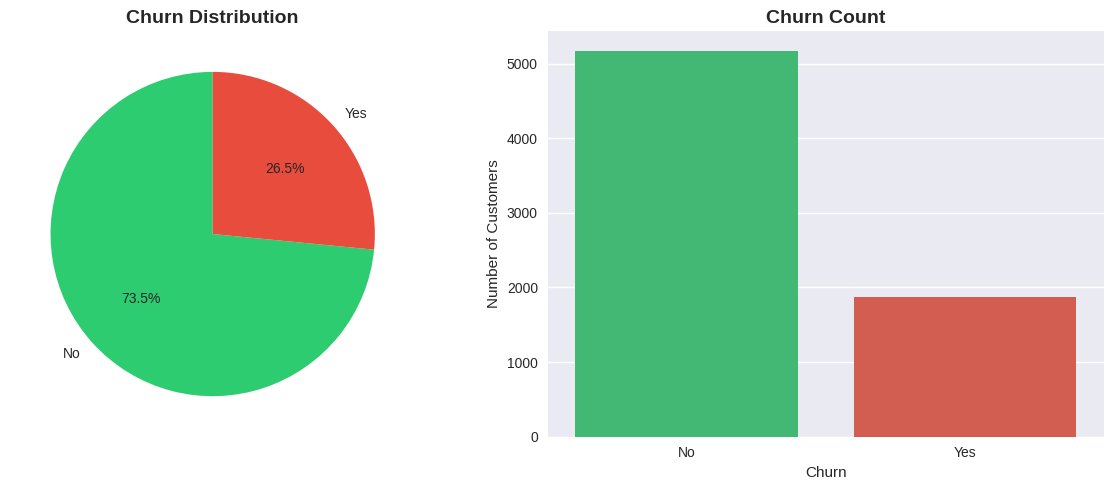

In [16]:
# Churn distribution visualize karo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=df, x='Churn', ax=axes[1],
              palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('/content/drive/My Drive/Capstone Project/Churn Prediction/plots/01_churn_distribution.png', dpi=150)
plt.show()

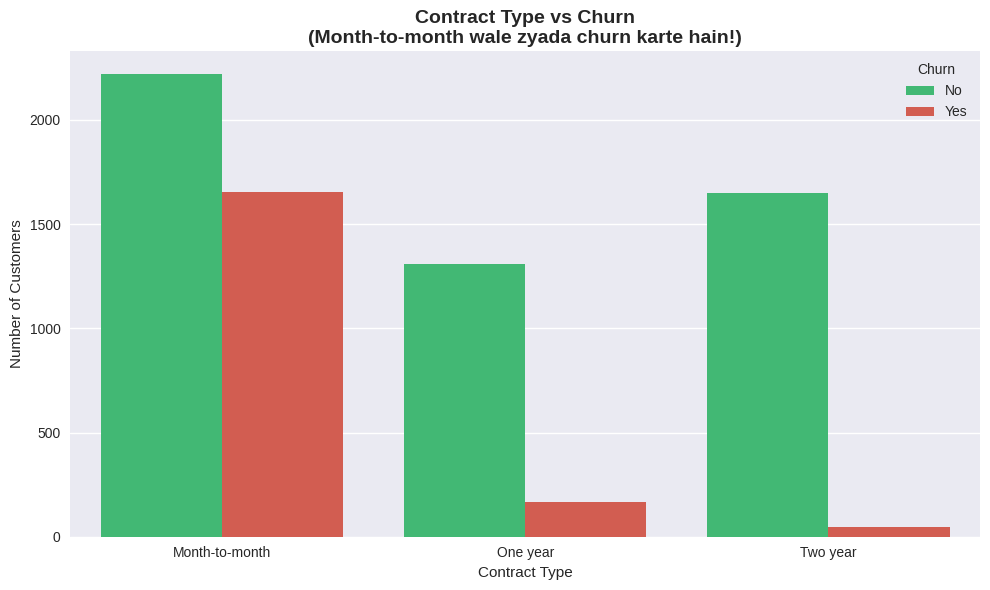

In [17]:
# Contract type ka churn pe impact
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn',
              palette=['#2ecc71', '#e74c3c'])
plt.title('Contract Type vs Churn\n(Month-to-month wale zyada churn karte hain!)',
          fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Capstone Project/Churn Prediction/plots/02_contract_vs_churn.png', dpi=150)
plt.show()

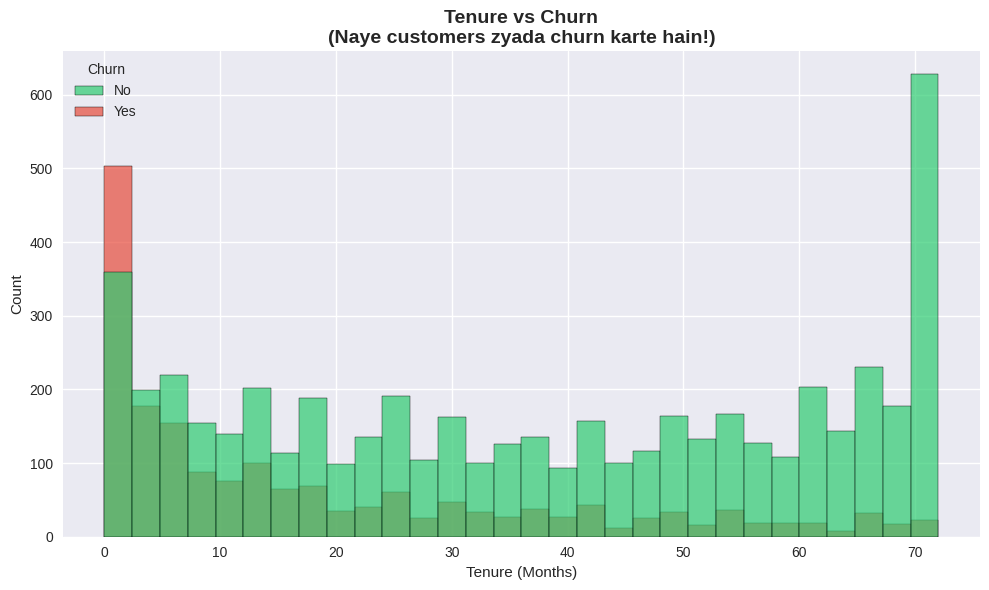

In [18]:
# Tenure distribution by churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn',
             bins=30, palette=['#2ecc71', '#e74c3c'],
             alpha=0.7)
plt.title('Tenure vs Churn\n(Naye customers zyada churn karte hain!)',
          fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Capstone Project/Churn Prediction/plots/03_tenure_vs_churn.png', dpi=150)
plt.show()

/tmp/ipykernel_43889/2580205896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
/tmp/ipykernel_43889/2580205896.py:9: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_43889/2580205896.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('/content/drive/My Drive/Capstone Project/Churn Prediction/plots/04_charges_vs_churn.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


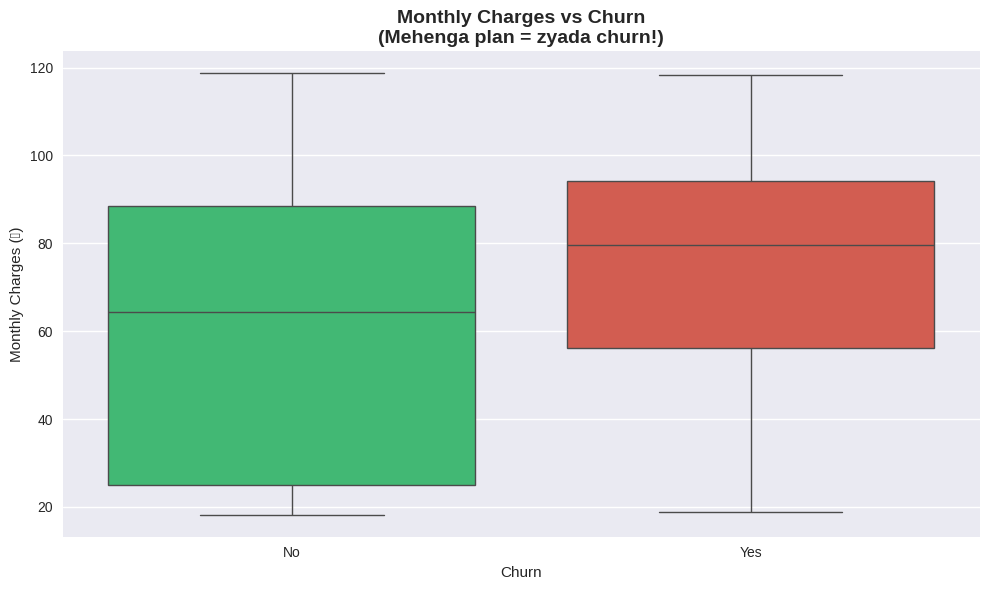

In [19]:
# Monthly charges comparison
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges vs Churn\n(Mehenga plan = zyada churn!)',
          fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges (₹)')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Capstone Project/Churn Prediction/plots/04_charges_vs_churn.png', dpi=150)
plt.show()

In [20]:
# Key findings print karo
print("=" * 50)
print("EDA KEY FINDINGS — CAPSTONE PROJECT")
print("=" * 50)

churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"\n1. Overall Churn Rate: {churn_rate:.1f}%")

month_to_month_churn = df[df['Contract'] == 'Month-to-month']['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f"2. Month-to-month customers churn rate: {month_to_month_churn:.1f}%")

avg_tenure_churn = df[df['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_no_churn = df[df['Churn'] == 'No']['tenure'].mean()
print(f"3. Avg tenure (churned): {avg_tenure_churn:.1f} months")
print(f"4. Avg tenure (stayed): {avg_tenure_no_churn:.1f} months")

avg_charge_churn = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_charge_no_churn = df[df['Churn'] == 'No']['MonthlyCharges'].mean()
print(f"5. Avg monthly charge (churned): ${avg_charge_churn:.2f}")
print(f"6. Avg monthly charge (stayed): ${avg_charge_no_churn:.2f}")

EDA KEY FINDINGS — CAPSTONE PROJECT

1. Overall Churn Rate: 26.5%
2. Month-to-month customers churn rate: 42.7%
3. Avg tenure (churned): 18.0 months
4. Avg tenure (stayed): 37.6 months
5. Avg monthly charge (churned): $74.44
6. Avg monthly charge (stayed): $61.27
